In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from garalen.config import ModelConfig
from garalen.simulation import run_simulation
from scipy.signal import find_peaks

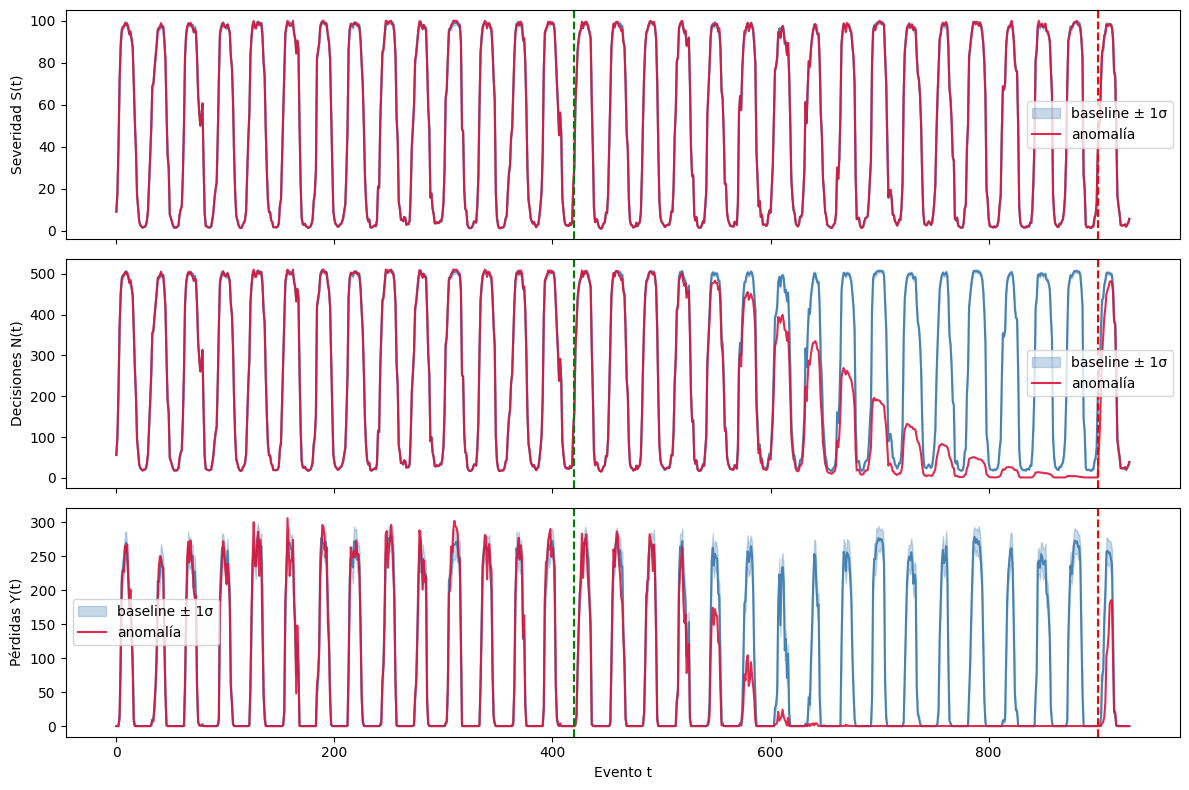

In [42]:
config = ModelConfig()
result = run_simulation(config)

t = np.arange(config.n_periods)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Severidad
S_baseline = result.S[:, 1:]
S_mean = S_baseline.mean(axis=1)
S_std = S_baseline.std(axis=1)
axes[0].fill_between(t, S_mean - S_std, S_mean + S_std, alpha=0.3, color="steelblue", label="baseline ± 1σ")
axes[0].plot(t, S_mean, color="steelblue", linewidth=1.5)
axes[0].plot(t, result.S[:, 0], color="crimson", alpha=0.9, label="anomalía")
axes[0].axvline(config.t_star, color="red", linestyle="--")
axes[0].axvline(config.past, color="green", linestyle="--")
axes[0].set_ylabel("Severidad S(t)")
axes[0].legend()

# Decisiones
N_baseline = result.N[:, 1:]
N_mean = N_baseline.mean(axis=1)
N_std = N_baseline.std(axis=1)
axes[1].fill_between(t, N_mean - N_std, N_mean + N_std, alpha=0.3, color="steelblue", label="baseline ± 1σ")
axes[1].plot(t, N_mean, color="steelblue", linewidth=1.5)
axes[1].plot(t, result.N[:, 0], color="crimson", alpha=0.9, label="anomalía")
axes[1].axvline(config.t_star, color="red", linestyle="--")
axes[1].axvline(config.past, color="green", linestyle="--")
axes[1].set_ylabel("Decisiones N(t)")
axes[1].legend()

# Pérdidas
Y_baseline = result.Y[:, 1:]
Y_mean = Y_baseline.mean(axis=1)
Y_std = Y_baseline.std(axis=1)
axes[2].fill_between(t, Y_mean - Y_std, Y_mean + Y_std, alpha=0.3, color="steelblue", label="baseline ± 1σ")
axes[2].plot(t, Y_mean, color="steelblue", linewidth=1.5)
axes[2].plot(t, result.Y[:, 0], color="crimson", alpha=0.9, label="anomalía")
axes[2].axvline(config.t_star, color="red", linestyle="--")
axes[2].axvline(config.past, color="green", linestyle="--")
axes[2].set_ylabel("Pérdidas Y(t)")
axes[2].legend()

axes[2].set_xlabel("Evento t")
plt.tight_layout()
plt.show()

In [43]:
print(f"S máximo: {result.S.max():.2f}")
print(f"S mínimo: {result.S.min():.2f}")
print(f"N máximo: {result.N.max()}")
print(f"N mínimo: {result.N.min()}")
print(f"Y baseline máximo: {result.Y[:, 1:].max()}")
print(f"Y baseline mínimo: {result.Y[:, 1:].min()}")
print(f"Y anomalía máximo: {result.Y[:, 0].max()}")
print(f"Y anomalía mínimo: {result.Y[:, 0].min()}")

S máximo: 100.00
S mínimo: 1.14
N máximo: 510.0
N mínimo: 1.0
Y baseline máximo: 324.0
Y baseline mínimo: 0.0
Y anomalía máximo: 306.0
Y anomalía mínimo: 0.0


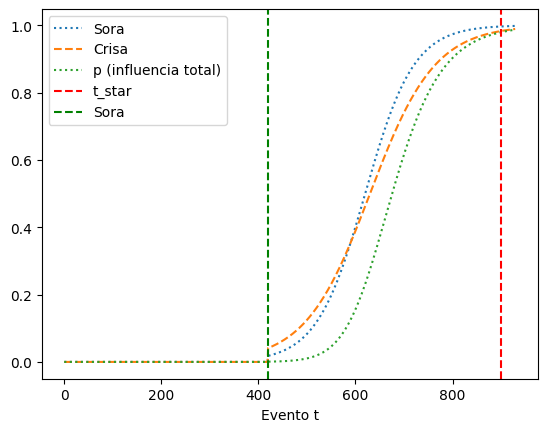

In [44]:
from garalen.losses import _sigmoid

edad = t - config.past
sora = _sigmoid(edad, config.k_s, config.t_s - config.past)
crisa = _sigmoid(edad, config.k_c, config.t_c - config.past)
sora[t < config.past] = 0.0
crisa[t < config.past] = 0.0
p = sora * crisa

plt.plot(t, sora, label="Sora", linestyle="dotted")
plt.plot(t, crisa, label="Crisa", linestyle="dashed")
plt.plot(t, p, label="p (influencia total)", linestyle="dotted")
plt.axvline(config.t_star, color="red", linestyle="--", label="t_star")
plt.axvline(config.past, color="green", linestyle="--", label="Sora")
plt.legend()
plt.xlabel("Evento t")
plt.show()

In [45]:
print(f"S máximo: {result.S.max():.2f}")
print(f"S mínimo: {result.S.min():.2f}")
print(f"N máximo: {result.N.max()}")

from garalen.losses import _failure_probability
from garalen.anomaly import compute_anomaly

N = result.N
q = _failure_probability(N, config)
p = compute_anomaly(config)
print(f"q_eff promedio pre t_star: {(q_crisa * (1 - p))[:config.t_star].mean():.3f}")
print(f"q máximo: {q.max():.3f}")
print(f"q promedio: {q.mean():.3f}")
print(f"p máximo pre t_star: {p[:config.t_star].max():.3f}")
print(f"p promedio pre t_star: {p[:config.t_star].mean():.3f}")
q_crisa = _failure_probability(result.N[:, 0], config)
print(f"q_eff promedio pre t_star: {(q_crisa * (1 - p))[:config.t_star].mean():.3f}")

S máximo: 100.00
S mínimo: 1.14
N máximo: 510.0
q_eff promedio pre t_star: 0.106
q máximo: 0.562
q promedio: 0.163
p máximo pre t_star: 1.000
p promedio pre t_star: 0.246
q_eff promedio pre t_star: 0.106


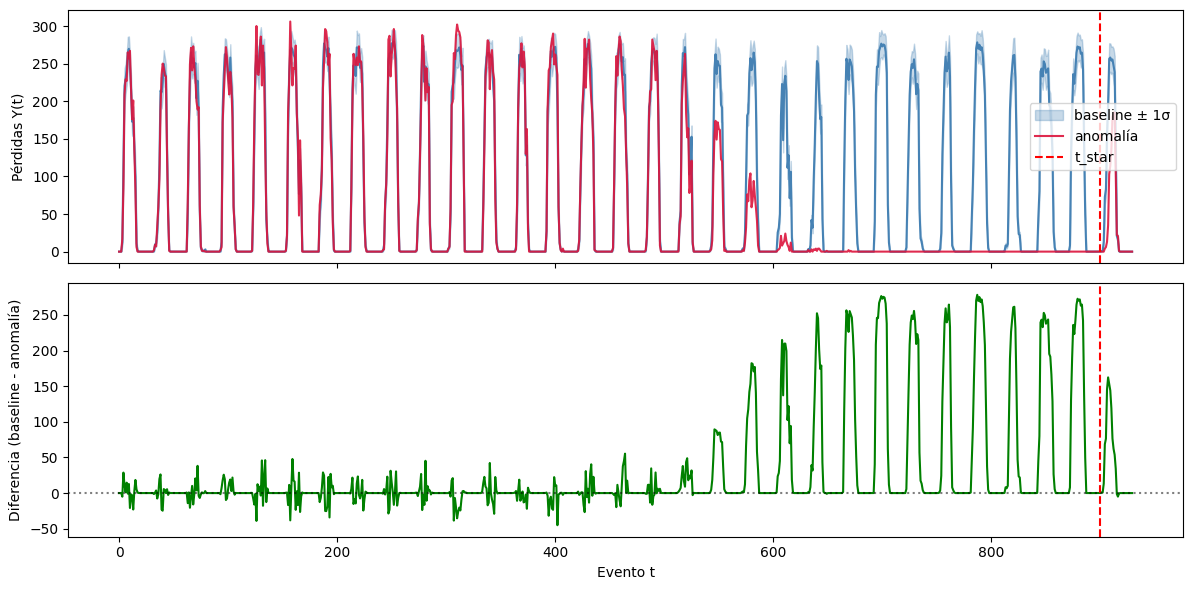

In [46]:
Y_baseline_mean = result.Y[:, 1:].mean(axis=1)
Y_anomaly = result.Y[:, 0]
diferencia = Y_baseline_mean - Y_anomaly

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].fill_between(t, Y_baseline_mean - result.Y[:, 1:].std(axis=1),
                        Y_baseline_mean + result.Y[:, 1:].std(axis=1),
                        alpha=0.3, color="steelblue", label="baseline ± 1σ")
axes[0].plot(t, Y_baseline_mean, color="steelblue", linewidth=1.5)
axes[0].plot(t, Y_anomaly, color="crimson", alpha=0.9, label="anomalía")
axes[0].axvline(config.t_star, color="red", linestyle="--", label="t_star")
axes[0].set_ylabel("Pérdidas Y(t)")
axes[0].legend()

axes[1].plot(t, diferencia, color="green")
axes[1].axvline(config.t_star, color="red", linestyle="--")
axes[1].axhline(0, color="black", linestyle=":", alpha=0.5)
axes[1].set_ylabel("Diferencia (baseline - anomalía)")
axes[1].set_xlabel("Evento t")

plt.tight_layout()
plt.show()

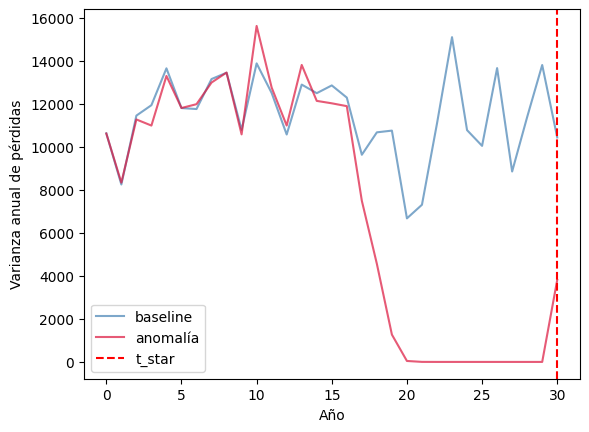

In [47]:
eventos_por_año = 30
n_años = config.n_periods // eventos_por_año

var_baseline = []
var_anomaly = []

for i in range(n_años):
    inicio = i * eventos_por_año
    fin = inicio + eventos_por_año
    var_baseline.append(result.Y[:, 1:][inicio:fin].mean(axis=1).var())
    var_anomaly.append(result.Y[:, 0][inicio:fin].var())

años = np.arange(n_años)

plt.plot(años, var_baseline, label="baseline", alpha=0.7, color="steelblue")
plt.plot(años, var_anomaly, label="anomalía", alpha=0.7, color="crimson")
plt.axvline(config.t_star / eventos_por_año, color="red", linestyle="--", label="t_star")
plt.ylabel("Varianza anual de pérdidas")
plt.xlabel("Año")
plt.legend()
plt.show()

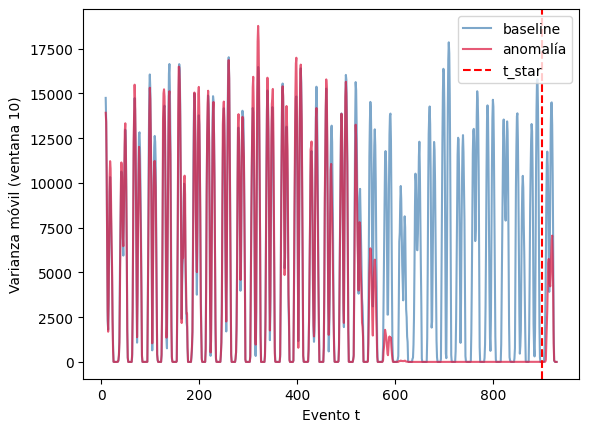

In [48]:
from pandas import Series

var_baseline = Series(result.Y[:, 1:].mean(axis=1)).rolling(10).var()
var_anomaly = Series(result.Y[:, 0]).rolling(10).var()

plt.plot(t, var_baseline, label="baseline", alpha=0.7, color="steelblue")
plt.plot(t, var_anomaly, label="anomalía", alpha=0.7, color="crimson")
plt.axvline(config.t_star, color="red", linestyle="--", label="t_star")
plt.ylabel("Varianza móvil (ventana 10)")
plt.xlabel("Evento t")
plt.legend()
plt.show()

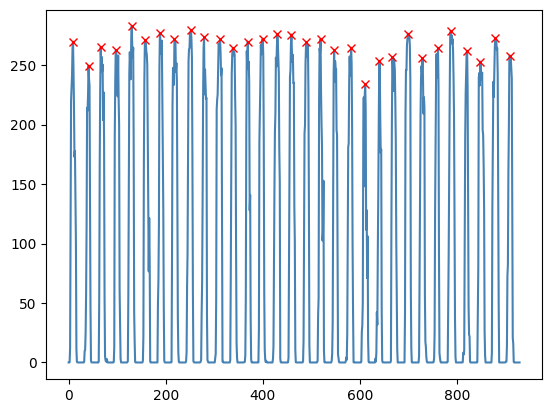

In [49]:
umbral = 2
Y_base_mean = result.Y[:, 1:].mean(axis=1)
es_cero = Y_base_mean <= umbral

cruces = np.diff(es_cero.astype(int))
inicios = np.where(cruces == -1)[0] + 1
fines = np.where(cruces == 1)[0]

picos_max = []
centros = []
for ini, fin in zip(inicios, fines):
    if fin > ini:
        segmento = Y_base_mean[ini:fin]
        idx_max = ini + segmento.argmax()
        picos_max.append(Y_base_mean[idx_max])
        centros.append(idx_max)

centros = np.array(centros)
picos_max = np.array(picos_max)

plt.plot(t, Y_base_mean, color="steelblue")
plt.plot(centros, picos_max, "x", color="red")
plt.show()

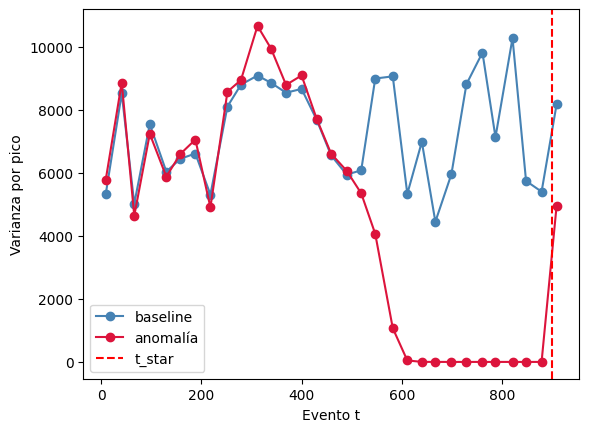

In [50]:
var_baseline_picos = []
var_anomaly_picos = []

for ini, fin in zip(inicios, fines):
    if fin > ini:
        seg_b = result.Y[:, 1:][ini:fin].mean(axis=1)
        seg_a = result.Y[:, 0][ini:fin]
        if len(seg_b) > 2:
            var_baseline_picos.append(seg_b.var())
            var_anomaly_picos.append(seg_a.var())

var_baseline_picos = np.array(var_baseline_picos)
var_anomaly_picos = np.array(var_anomaly_picos)

plt.plot(centros, var_baseline_picos, label="baseline", marker="o", color="steelblue")
plt.plot(centros, var_anomaly_picos, label="anomalía", marker="o", color="crimson")
plt.axvline(config.t_star, color="red", linestyle="--", label="t_star")
plt.ylabel("Varianza por pico")
plt.xlabel("Evento t")
plt.legend()
plt.show()

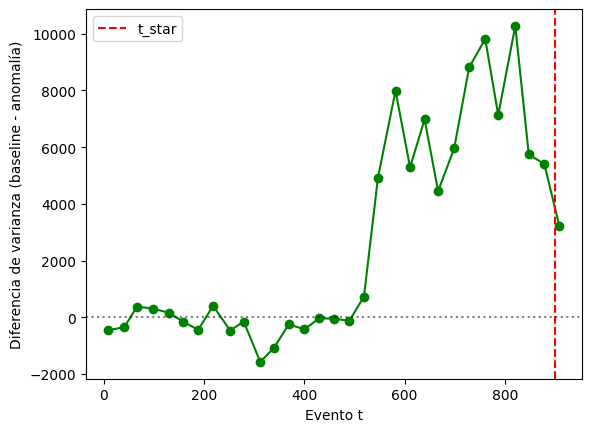

In [51]:
diff_var = np.array(var_baseline_picos) - np.array(var_anomaly_picos)

plt.plot(centros, diff_var, marker="o", color="green")
plt.axvline(config.t_star, color="red", linestyle="--", label="t_star")
plt.axhline(0, color="black", linestyle=":", alpha=0.5)
plt.ylabel("Diferencia de varianza (baseline - anomalía)")
plt.xlabel("Evento t")
plt.legend()
plt.show()

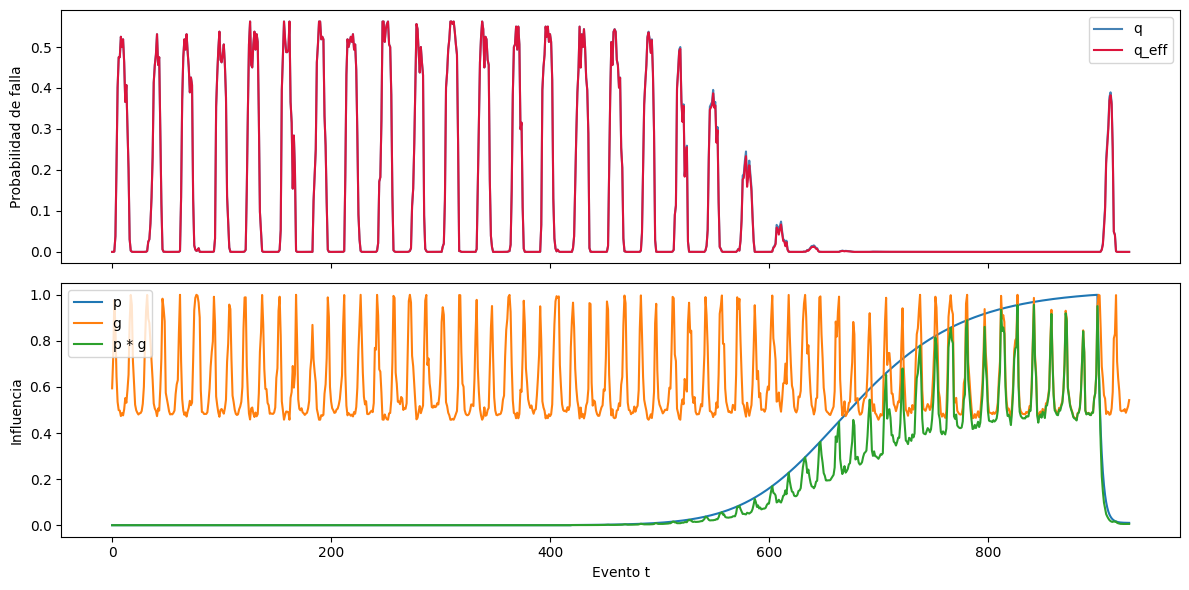

In [52]:
from garalen.losses import _failure_probability
from garalen.anomaly import compute_anomaly

q_crisa = _failure_probability(result.N[:, 0], config)
p = compute_anomaly(config)
g = np.exp(-0.5 * ((result.S[:, 0] - config.S_0) / config.sigma_g) ** 2)
q_eff = q_crisa * (1 - p * g)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(t, q_crisa, label="q", color="steelblue")
axes[0].plot(t, q_eff, label="q_eff", color="crimson")
axes[0].set_ylabel("Probabilidad de falla")
axes[0].legend()

axes[1].plot(t, p, label="p")
axes[1].plot(t, g, label="g")
axes[1].plot(t, p * g, label="p * g")
axes[1].set_ylabel("Influencia")
axes[1].legend()

axes[1].set_xlabel("Evento t")
plt.tight_layout()
plt.show()

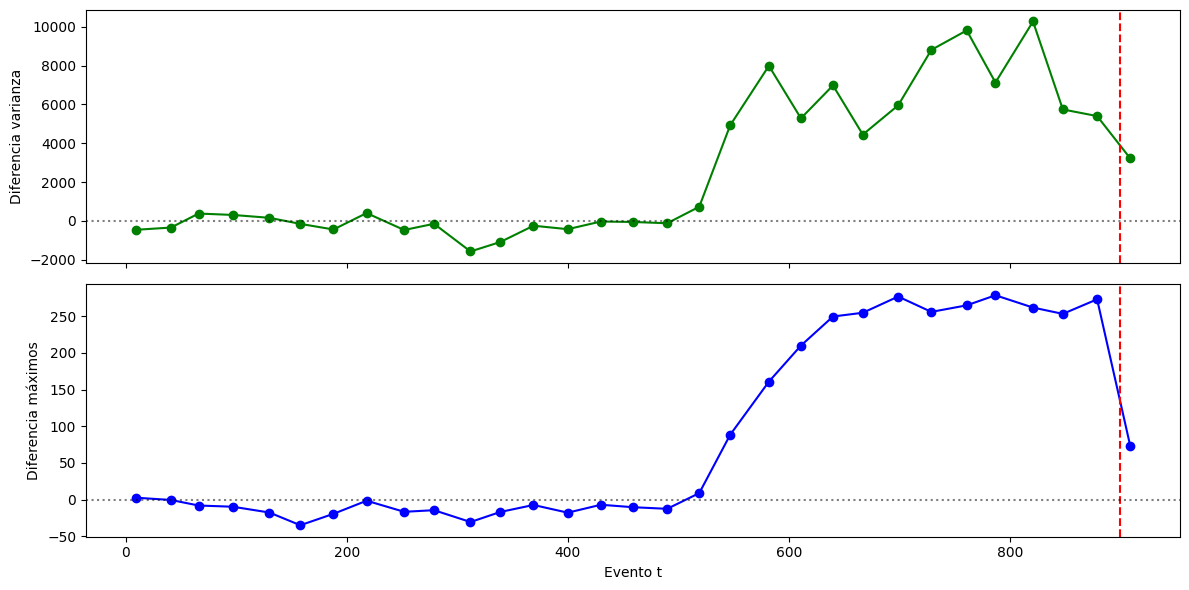

In [53]:
max_baseline = np.array([result.Y[:, 1:][ini:fin].mean(axis=1).max() for ini, fin in zip(inicios, fines) if fin > ini])
max_anomaly = np.array([result.Y[:, 0][ini:fin].max() for ini, fin in zip(inicios, fines) if fin > ini])

diff_max = max_baseline - max_anomaly
diff_var = np.array(var_baseline_picos) - np.array(var_anomaly_picos)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(centros, diff_var, marker="o", color="green")
axes[0].axvline(config.t_star, color="red", linestyle="--")
axes[0].axhline(0, color="black", linestyle=":", alpha=0.5)
axes[0].set_ylabel("Diferencia varianza")

axes[1].plot(centros, diff_max, marker="o", color="blue")
axes[1].axvline(config.t_star, color="red", linestyle="--")
axes[1].axhline(0, color="black", linestyle=":", alpha=0.5)
axes[1].set_ylabel("Diferencia máximos")
axes[1].set_xlabel("Evento t")

plt.tight_layout()
plt.show()

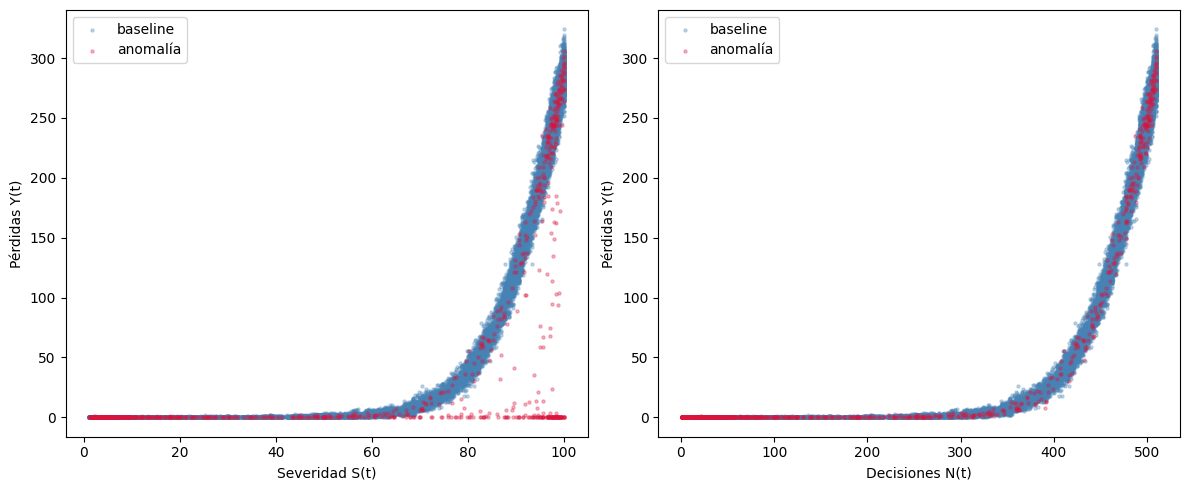

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(result.S[:, 1:], result.Y[:, 1:], alpha=0.3, s=5, color="steelblue", label="baseline")
axes[0].scatter(result.S[:, 0], result.Y[:, 0], alpha=0.3, s=5, color="crimson", label="anomalía")
axes[0].set_xlabel("Severidad S(t)")
axes[0].set_ylabel("Pérdidas Y(t)")
axes[0].legend()

axes[1].scatter(result.N[:, 1:], result.Y[:, 1:], alpha=0.3, s=5, color="steelblue", label="baseline")
axes[1].scatter(result.N[:, 0], result.Y[:, 0], alpha=0.3, s=5, color="crimson", label="anomalía")
axes[1].set_xlabel("Decisiones N(t)")
axes[1].set_ylabel("Pérdidas Y(t)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [55]:
S_crisa = result.S[:, 0]

print(f"g promedio: {g.mean():.3f}")
print(f"g en S bajo (S<30): {g[S_crisa < 30].mean():.3f}")
print(f"g en S alto (S>70): {g[S_crisa > 70].mean():.3f}")
print(f"p promedio: {p.mean():.3f}")
print(f"p en S bajo (S<30): {p[S_crisa < 30].mean():.3f}")
print(f"p en S alto (S>70): {p[S_crisa > 70].mean():.3f}")
print(f"p*g promedio pre t_star: {(p*g)[:config.t_star].mean():.3f}")
print(f"p máximo pre t_star: {p[:config.t_star].max():.3f}")

g promedio: 0.615
g en S bajo (S<30): 0.568
g en S alto (S>70): 0.564
p promedio: 0.243
p en S bajo (S<30): 0.247
p en S alto (S>70): 0.240
p*g promedio pre t_star: 0.149
p máximo pre t_star: 1.000
